In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import networkx as nx
import warnings

import matplotlib.font_manager as fm

# 한글 폰트 설정 (실행 환경에 따라 폰트가 다를 수 있음, 기본적으로 깨짐 방지용 설정)
try:
    font_path = r'C:\Windows\Fonts\malgun.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('final.csv')
df.drop('matchId', axis=1, inplace=True)
df

,blueWins,blueWardsPlaced,blueControlWardsPlaced,blueWardsDestroyed,blueControlWardsDestroyed,blueFirstBlood,blueKills,blueDeaths,blueAssists,blueDragons,...,redTowersDestroyed,redPlatesDestroyed,redTotalGold,redTotalExperience,redTotalMinionsKilled,redTotalJungleMinionsKilled,redFirstTurret,redInhibitorsDestroyed,redFirstDragon,gameDuration
0,1,43,9,10,3,1,12,15,14,0,...,1,3,29411,30691,349,103,1,0,1,2343.847
1,1,36,11,5,3,1,8,5,9,1,...,0,4,24827,30167,403,106,0,0,0,1939.513
2,1,33,11,6,2,1,10,14,6,1,...,1,2,28200,29638,341,100,1,0,0,1553.700
3,0,28,5,8,5,0,14,23,9,1,...,1,6,31584,31717,355,82,1,0,1,2213.758
4,1,29,7,6,5,1,14,13,19,0,...,0,1,27239,29741,340,84,0,0,1,1470.118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94350,1,81,10,15,7,1,15,3,13,0,...,0,1,23074,28482,395,90,0,0,1,1168.248
94351,1,29,6,13,3,1,16,6,14,1,...,0,1,24500,28283,377,66,0,0,1,1339.719
94352,0,29,5,12,5,0,6,12,9,0,...,0,3,27488,31347,371,94,0,0,1,1399.935
94353,0,36,8,8,1,0,14,20,19,2,...,0,4,31258,30936,356,76,0,0,0,1909.138


In [17]:
print(df.columns.tolist())

['blueWins', 'blueWardsPlaced', 'blueControlWardsPlaced', 'blueWardsDestroyed', 'blueControlWardsDestroyed', 'blueFirstBlood', 'blueKills', 'blueDeaths', 'blueAssists', 'blueDragons', 'blueHeralds', 'blueVoidGrubs', 'blueTowersDestroyed', 'bluePlatesDestroyed', 'blueTotalGold', 'blueTotalExperience', 'blueTotalMinionsKilled', 'blueTotalJungleMinionsKilled', 'blueFirstTurret', 'blueInhibitorsDestroyed', 'blueFirstDragon', 'redWardsPlaced', 'redControlWardsPlaced', 'redWardsDestroyed', 'redControlWardsDestroyed', 'redFirstBlood', 'redKills', 'redDeaths', 'redAssists', 'redDragons', 'redHeralds', 'redVoidGrubs', 'redTowersDestroyed', 'redPlatesDestroyed', 'redTotalGold', 'redTotalExperience', 'redTotalMinionsKilled', 'redTotalJungleMinionsKilled', 'redFirstTurret', 'redInhibitorsDestroyed', 'redFirstDragon', 'gameDuration']


In [18]:
import pandas as pd

print("\n--- 2. 데이터 전처리 및 변수 재설계 ---")

# 1. 식별자 제거
if 'matchId' in df.columns:
    df = df.drop('matchId', axis=1)
    print("- matchId 컬럼 제거 완료")

# 2. 탈주자(AFK) 제거 (절대값 기준)
# 게임 자체가 성립되지 않은 판을 거르는 것이므로 절대값 사용이 맞음
print("- 이상치 제거 1단계: 탈주자(AFK) 의심 데이터 제거 (기준: 15분 골드 < 20,000)")
before_len = len(df)
df = df[(df['blueTotalGold'] > 20000) & (df['redTotalGold'] > 20000)].copy()
print(f"  제거된 레코드 수: {before_len - len(df)}")

# 3. 변수 재설계: 격차(Diff) 변수 생성 (핵심 로직 수정)
# 3-1. 수치형 변수 격차 계산 (Blue - Red)
numeric_pairs = [
    ('TotalGold', 'blueTotalGold', 'redTotalGold'),
    ('TotalExperience', 'blueTotalExperience', 'redTotalExperience'),
    ('Kills', 'blueKills', 'redKills'),
    ('Deaths', 'blueDeaths', 'redDeaths'),
    ('Assists', 'blueAssists', 'redAssists'),
    ('WardsPlaced', 'blueWardsPlaced', 'redWardsPlaced'),
    ('ControlWardsPlaced', 'blueControlWardsPlaced', 'redControlWardsPlaced'),
    ('WardsDestroyed', 'blueWardsDestroyed', 'redWardsDestroyed'),
    ('Dragons', 'blueDragons', 'redDragons'),
    ('Heralds', 'blueHeralds', 'redHeralds'),
    ('VoidGrubs', 'blueVoidGrubs', 'redVoidGrubs'),
    ('TowersDestroyed', 'blueTowersDestroyed', 'redTowersDestroyed'),
    ('PlatesDestroyed', 'bluePlatesDestroyed', 'redPlatesDestroyed'),
    ('MinionsKilled', 'blueTotalMinionsKilled', 'redTotalMinionsKilled'),
    ('JungleMinionsKilled', 'blueTotalJungleMinionsKilled', 'redTotalJungleMinionsKilled'),
    ('InhibitorsDestroyed', 'blueInhibitorsDestroyed', 'redInhibitorsDestroyed')
]

diff_cols = []
for name, blue, red in numeric_pairs:
    if blue in df.columns and red in df.columns:
        df[f'Diff_{name}'] = df[blue] - df[red]
        diff_cols.append(f'Diff_{name}')

# 3-2. First 관련 변수 격차 계산 (1:블루획득, 0:없음, -1:레드획득)
# 기존 코드에서 삭제했던 First 변수를 살려서 점수화함
first_pairs = [
    ('FirstTurret', 'blueFirstTurret', 'redFirstTurret'),
    ('FirstDragon', 'blueFirstDragon', 'redFirstDragon'),
    ('FirstBlood', 'blueFirstBlood', 'redFirstBlood')
]

for name, blue, red in first_pairs:
    if blue in df.columns and red in df.columns:
        df[f'Diff_{name}'] = df[blue] - df[red]
        diff_cols.append(f'Diff_{name}')

# 4. 최종 컬럼 선택 (Diff 변수 + 승패)
# 기존의 원본(blue..., red...) 컬럼은 이제 삭제
final_columns = diff_cols + ['blueWins']
df = df[final_columns]
print(f"  변수 재설계 : {len(df.columns)}개 컬럼")

# 5. 이상치 제거 2단계 (격차 변수 기준 IQR)
print("- 이상치 제거 2단계: 고의 패배 의심 데이터 제거)")
# 가장 중요한 골드와 경험치 차이가 비정상적으로 큰 게임(트롤링/대리게임 등) 제거
target_outlier_cols = ['Diff_TotalGold', 'Diff_TotalExperience']

Q1 = df[target_outlier_cols].quantile(0.25)
Q3 = df[target_outlier_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_condition = (
    (df['Diff_TotalGold'] < (Q1['Diff_TotalGold'] - 1.5 * IQR['Diff_TotalGold'])) |
    (df['Diff_TotalGold'] > (Q3['Diff_TotalGold'] + 1.5 * IQR['Diff_TotalGold'])) |
    (df['Diff_TotalExperience'] < (Q1['Diff_TotalExperience'] - 1.5 * IQR['Diff_TotalExperience'])) |
    (df['Diff_TotalExperience'] > (Q3['Diff_TotalExperience'] + 1.5 * IQR['Diff_TotalExperience']))
)

before_len2 = len(df)
df = df[~outlier_condition]
print(f"  제거된 레코드 수: {before_len2 - len(df)}")
print(f"  최종 분석 데이터 수: {len(df)}")

# 데이터 확인
print("\n[최종 데이터 요약]")
df.info()


--- 2. 데이터 전처리 및 변수 재설계 ---
- 이상치 제거 1단계: 탈주자(AFK) 의심 데이터 제거 (기준: 15분 골드 < 20,000)
  제거된 레코드 수: 33
  변수 재설계 : 20개 컬럼
- 이상치 제거 2단계: 고의 패배 의심 데이터 제거)
  제거된 레코드 수: 961
  최종 분석 데이터 수: 93361

[최종 데이터 요약]
<class 'pandas.core.frame.DataFrame'>
Index: 93361 entries, 0 to 94354
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Diff_TotalGold            93361 non-null  int64
 1   Diff_TotalExperience      93361 non-null  int64
 2   Diff_Kills                93361 non-null  int64
 3   Diff_Deaths               93361 non-null  int64
 4   Diff_Assists              93361 non-null  int64
 5   Diff_WardsPlaced          93361 non-null  int64
 6   Diff_ControlWardsPlaced   93361 non-null  int64
 7   Diff_WardsDestroyed       93361 non-null  int64
 8   Diff_Dragons              93361 non-null  int64
 9   Diff_Heralds              93361 non-null  int64
 10  Diff_VoidGrubs            93361 non-null  int64
 11  Di


## 4. 기초 데이터 분석 및 시각화 ##

[4-1] 승리/패배 집단 간 핵심 지표(골드, 경험치, 킬) 분포 비교


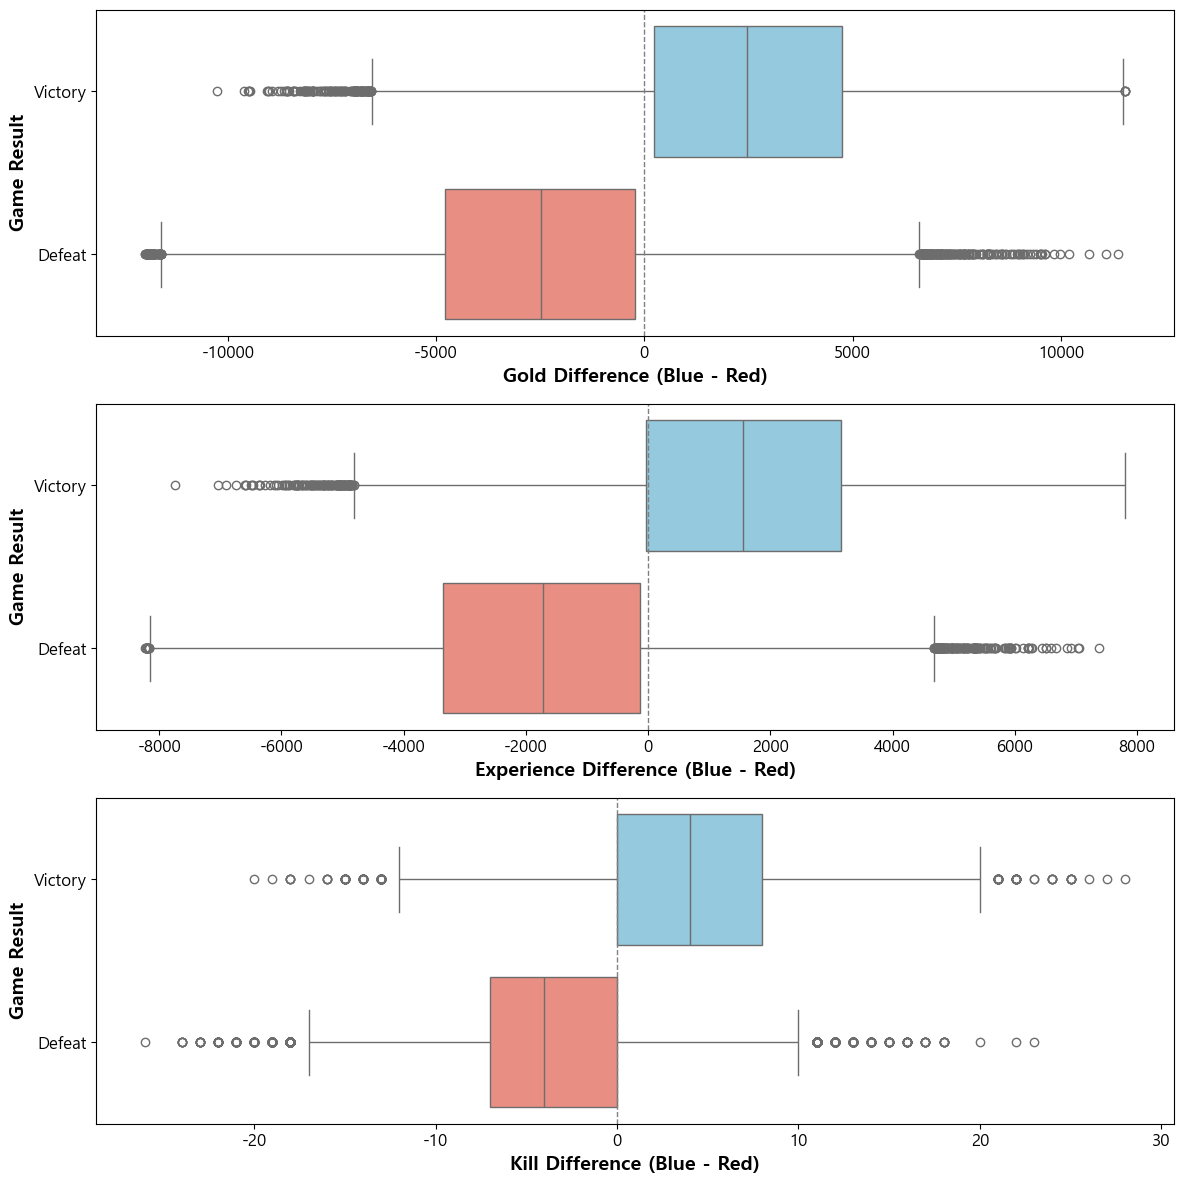


               [그림 1. 승/패(Y축)에 따른 킬, 골드, 경험치 격차의 분포 비교]               

- 해석: 승리 팀은 세 지표 모두에서 양수(+) 값을, 패배 팀은 음수(-) 값을 보이며,
        두 집단의 분포가 0을 기점으로 명확하게 분리되는 경향을 보입니다.

## 5. 통계적 가설 검정 (T-Test) ##

[5-1] 독립변수(격차)와 종속변수(승패) 간의 유의성 검증

             [표 1. 주요 변수별 승패와의 상관관계 및 T-Test 결과 (영향력 순)]              

                 Feature Correlation(r) T-Statistic  P-Value
          Diff_TotalGold          0.599      228.60 0.00e+00
    Diff_TotalExperience          0.576      215.28 0.00e+00
              Diff_Kills          0.551      201.64 0.00e+00
             Diff_Deaths         -0.551     -201.64 0.00e+00
            Diff_Assists          0.456      156.57 0.00e+00
      Diff_MinionsKilled          0.388      128.61 0.00e+00
    Diff_TowersDestroyed          0.382      126.66 0.00e+00
    Diff_PlatesDestroyed          0.370      122.34 0.00e+00
        Diff_FirstTurret          0.316      102.87 0.00e+00
            Diff_Dragons          0.292       92.63 0.00e+00
Diff_JungleMinionsKi

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import numpy as np

# ==============================================================================
# [설정] 그래프 스타일 및 폰트 크기 (보고서용)
# ==============================================================================
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['axes.unicode_minus'] = False

def print_caption(text, type="figure"):
    print("\n" + "="*70)
    print(f"[{text}]".center(70))
    print("="*70 + "\n")

# 시각화용 승패 컬럼 생성
if 'Result' not in df.columns:
    df['Result'] = df['blueWins'].map({1: 'Victory', 0: 'Defeat'})

print("\n## 4. 기초 데이터 분석 및 시각화 ##")

# ==============================================================================
# 4-1. [First] 승패(Y축)에 따른 핵심 3대 지표(골드, 경험치, 킬) 분포 확인
# ==============================================================================
print("\n[4-1] 승리/패배 집단 간 핵심 지표(골드, 경험치, 킬) 분포 비교")

# 분석할 3대장 변수
key_metrics = ['Diff_TotalGold', 'Diff_TotalExperience', 'Diff_Kills']
metric_labels = ['Gold Difference', 'Experience Difference', 'Kill Difference']

# 3행 1열의 가로형 박스플롯 생성
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, (col, label) in enumerate(zip(key_metrics, metric_labels)):
    # 핵심: 타겟(Result)을 Y축에 배치하여 분포 차이를 직관적으로 표현
    sns.boxplot(x=col, y='Result', data=df, ax=axes[i], 
                palette={'Victory': 'skyblue', 'Defeat': 'salmon'}, 
                orient='h', order=['Victory', 'Defeat'])
    
    # 스타일링: 제목 제거, 축 라벨 강조, 0 기준선 추가
    axes[i].set_title('') 
    axes[i].set_ylabel('Game Result', fontweight='bold')
    axes[i].set_xlabel(f'{label} (Blue - Red)', fontweight='bold')
    axes[i].axvline(0, color='gray', linestyle='--', linewidth=1) # 0점 기준선

plt.tight_layout()
plt.show()

print_caption("그림 1. 승/패(Y축)에 따른 킬, 골드, 경험치 격차의 분포 비교", type="figure")
print("- 해석: 승리 팀은 세 지표 모두에서 양수(+) 값을, 패배 팀은 음수(-) 값을 보이며,")
print("        두 집단의 분포가 0을 기점으로 명확하게 분리되는 경향을 보입니다.")


# ==============================================================================
# 4-2. [Next] 주요 지표와 승패의 관계 분석 (T-Test)
# ==============================================================================
print("\n## 5. 통계적 가설 검정 (T-Test) ##")
print("\n[5-1] 독립변수(격차)와 종속변수(승패) 간의 유의성 검증")

t_test_results = []
# Diff로 시작하는 모든 수치형 변수 추출
features = [col for col in df.columns if col.startswith('Diff_')]

for col in features:
    # 집단 분리
    win_group = df[df['blueWins'] == 1][col]
    lose_group = df[df['blueWins'] == 0][col]
    
    # 1. T-Test (Welch's)
    t_stat, p_val = stats.ttest_ind(win_group, lose_group, equal_var=False)
    
    # 2. 점이연 상관계수 (Point-Biserial)
    # 승패(0/1)와 연속형 변수 간의 상관관계
    corr, _ = stats.pointbiserialr(df[col], df['blueWins'])
    
    t_test_results.append({
        'Feature': col,
        'Correlation(r)': corr,
        'T-Statistic': t_stat,
        'P-Value': p_val
    })

# 상관계수(영향력) 절대값 순 정렬
t_test_df = pd.DataFrame(t_test_results).sort_values(by='Correlation(r)', key=abs, ascending=False)

# 결과 표 출력
print_caption("표 1. 주요 변수별 승패와의 상관관계 및 T-Test 결과 (영향력 순)", type="table")

# 가독성을 위해 포맷팅하여 상위 15개 출력
display_cols = ['Feature', 'Correlation(r)', 'T-Statistic', 'P-Value']
print(t_test_df[display_cols].head(15).to_string(index=False, formatters={
    'Correlation(r)': '{:,.3f}'.format,
    'T-Statistic': '{:,.2f}'.format,
    'P-Value': '{:.2e}'.format
}))

print("\n* 결론: 모든 주요 변수의 P-Value가 0.05 미만으로, 승/패 집단 간에 통계적으로 유의미한 차이가 존재함을 확인.")


## 5. 통계적 가설 검정: T-테스트 (T-Test) 분석 ##
- 목적: 승리 팀과 패배 팀 간의 평균 지표 차이가 통계적으로 얼마나 유의미한지(T-값) 검증


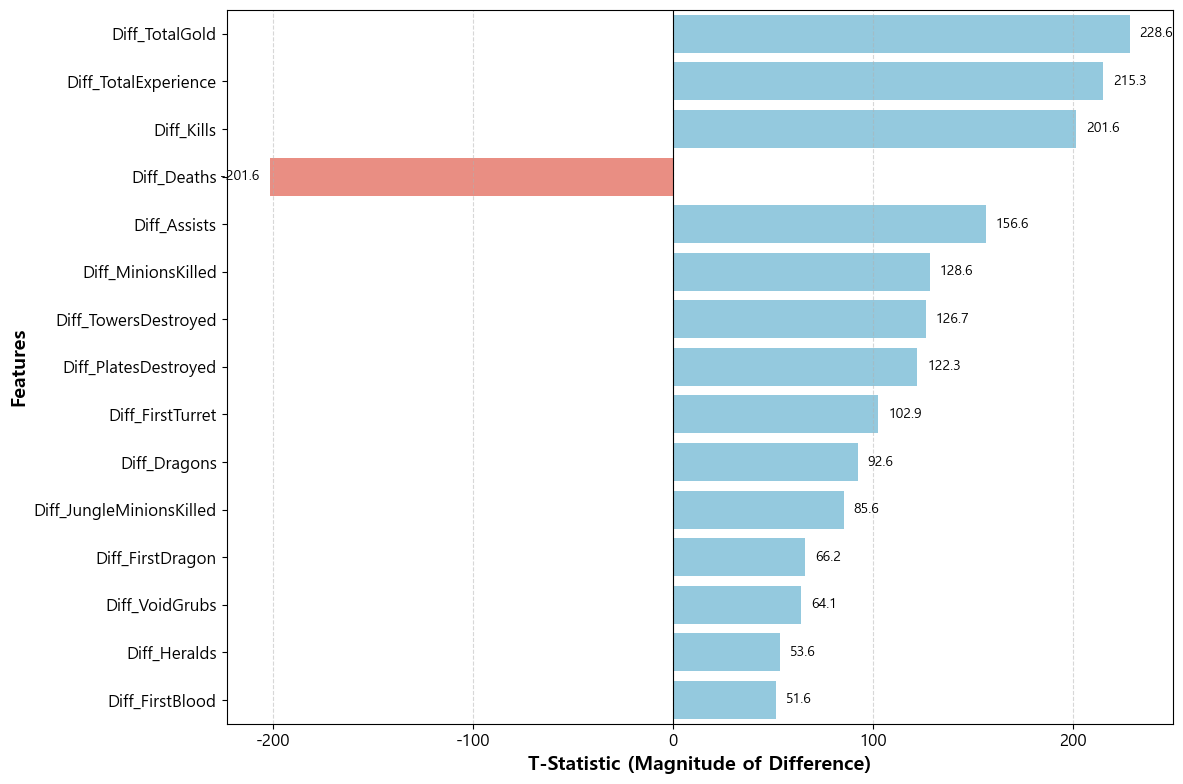


               [그림 3] 승패 집단 간 T-테스트 통계량(T-값) 상위 15개 변수                

[분석 결과] T-값이 큰 순서대로 정렬된 주요 변수 목록
------------------------------------------------------------
                 Feature T-Statistic  P-Value
          Diff_TotalGold      228.60 0.00e+00
    Diff_TotalExperience      215.28 0.00e+00
              Diff_Kills      201.64 0.00e+00
             Diff_Deaths     -201.64 0.00e+00
            Diff_Assists      156.57 0.00e+00
      Diff_MinionsKilled      128.61 0.00e+00
    Diff_TowersDestroyed      126.66 0.00e+00
    Diff_PlatesDestroyed      122.34 0.00e+00
        Diff_FirstTurret      102.87 0.00e+00
            Diff_Dragons       92.63 0.00e+00
Diff_JungleMinionsKilled       85.59 0.00e+00
        Diff_FirstDragon       66.24 0.00e+00
          Diff_VoidGrubs       64.10 0.00e+00
            Diff_Heralds       53.56 0.00e+00
         Diff_FirstBlood       51.56 0.00e+00
------------------------------------------------------------
* 해석: T-값의 절대값이 클수록 두 집단(승/패) 간의 차이가

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# (이전 단계의 df 데이터프레임이 전처리되어 있다고 가정)
# 만약 df가 없다면 전처리 코드를 먼저 실행해주세요.

print("\n## 5. 통계적 가설 검정: T-테스트 (T-Test) 분석 ##")
print("- 목적: 승리 팀과 패배 팀 간의 평균 지표 차이가 통계적으로 얼마나 유의미한지(T-값) 검증")

# 1. T-테스트 수행 및 T-값 계산
t_test_results = []
features = [col for col in df.columns if col.startswith('Diff_')]

for col in features:
    # 승리 그룹 vs 패배 그룹 데이터 분리
    win_group = df[df['blueWins'] == 1][col]
    lose_group = df[df['blueWins'] == 0][col]
    
    # T-Test (Welch's T-test) 수행
    t_stat, p_val = stats.ttest_ind(win_group, lose_group, equal_var=False)
    
    t_test_results.append({
        'Feature': col,
        'T-Statistic': t_stat,  # ★ 핵심: T-값
        'P-Value': p_val
    })

# 2. T-값 절대값 기준으로 정렬 (영향력이 큰 순서)
t_test_df = pd.DataFrame(t_test_results).sort_values(by='T-Statistic', key=abs, ascending=False)

# 3. 상위 변수 시각화 (Bar Chart - T-값 기준)
plt.figure(figsize=(12, 8))

# 상위 15개만 시각화
top_n = 15
top_t_data = t_test_df.head(top_n)

# 색상 구분 (양수: 파랑/승리요인, 음수: 빨강/패배요인)
colors = ['skyblue' if x > 0 else 'salmon' for x in top_t_data['T-Statistic']]

barplot = sns.barplot(x='T-Statistic', y='Feature', data=top_t_data, palette=colors)
plt.title('') # 제목 제거 (캡션으로 대체)
plt.xlabel('T-Statistic (Magnitude of Difference)', fontweight='bold')
plt.ylabel('Features', fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8) # 0 기준선
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 막대 옆에 수치 표시
for index, row in enumerate(top_t_data.itertuples()):
    # 위치 조정
    val = row._2  # T-Statistic
    offset = 5 if val > 0 else -5
    ha = 'left' if val > 0 else 'right'
    plt.text(val + offset, index, f'{val:.1f}', va='center', ha=ha, fontsize=10)

plt.tight_layout()
plt.show()

# 캡션 출력
print("\n" + "="*70)
print(f"[그림 3] 승패 집단 간 T-테스트 통계량(T-값) 상위 {top_n}개 변수".center(70))
print("="*70 + "\n")

# 4. 결과 표 출력
print(f"[분석 결과] T-값이 큰 순서대로 정렬된 주요 변수 목록")
print("-" * 60)
# 가독성을 위해 포맷팅
print(t_test_df.head(top_n).to_string(index=False, formatters={
    'T-Statistic': '{:,.2f}'.format,
    'P-Value': '{:.2e}'.format
}))
print("-" * 60)
print("* 해석: T-값의 절대값이 클수록 두 집단(승/패) 간의 차이가 명확함을 의미합니다.")
print("  (일반적으로 절대값 2 이상이면 유의미하다고 보는데, 여기서는 100 이상으로 매우 큽니다.)")

# 다음 단계 분석을 위해 변수 리스트 저장
selected_features = t_test_df['Feature'].tolist()


## 5-2. 변수 간 관계 시각화: 산점도 (Scatter Plot) ##


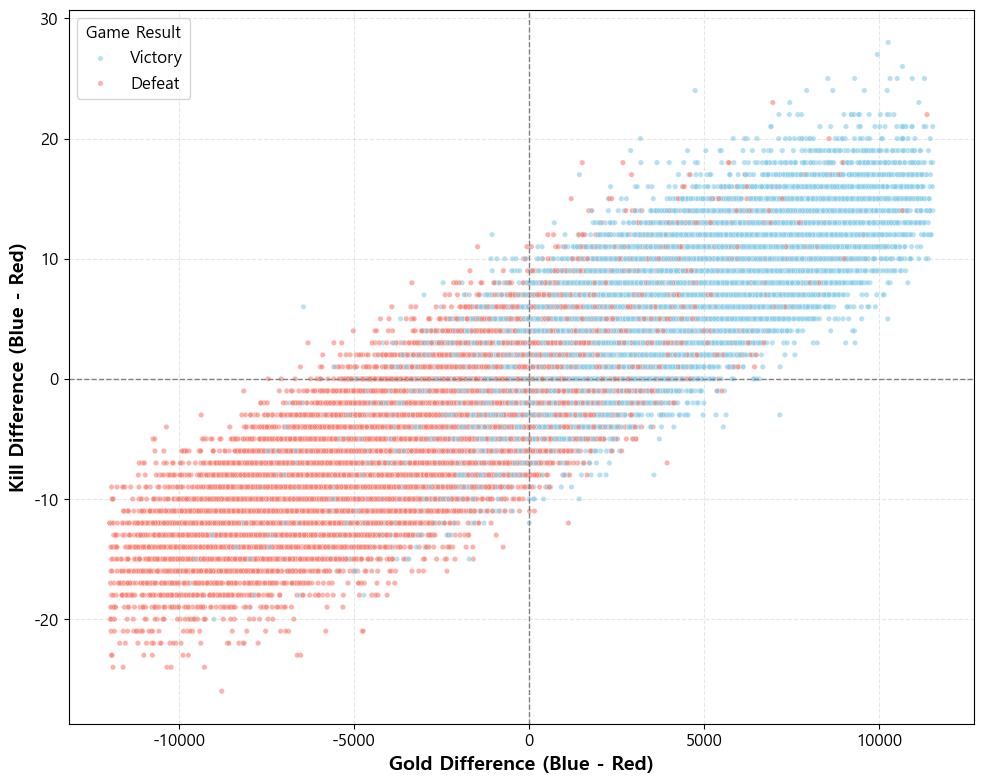

----------------------------------------------------------------------
                   [그림] 골드 격차와 킬 격차의 관계 및 승패 분포 산점도                   
----------------------------------------------------------------------
* 해석:
  1. 양의 상관관계: 킬을 많이 할수록 골드 격차도 커지는 선형적인 관계가 뚜렷합니다.
  2. 집단 분리: 1사분면(양수)에는 승리(Victory), 3사분면(음수)에는 패배(Defeat)가
     명확하게 군집을 이루고 있어, 이 두 변수만으로도 승패 예측이 가능함을 시사합니다.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# (df 데이터프레임이 준비된 상태여야 합니다)

print("\n## 5-2. 변수 간 관계 시각화: 산점도 (Scatter Plot) ##")

plt.figure(figsize=(10, 8))

# 골드 차이(X) vs 킬 차이(Y) 산점도
# hue='Result'로 승/패 색상 구분
sns.scatterplot(
    data=df, 
    x='Diff_TotalGold', 
    y='Diff_Kills', 
    hue='Result', 
    palette={'Victory': 'skyblue', 'Defeat': 'salmon'},
    alpha=0.6,  # 투명도 (데이터가 많으므로 겹침 확인용)
    s=15        # 점 크기
)

# 0점 기준선 (격차가 없는 지점)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

plt.title('') # 제목 제거 (캡션 사용)
plt.xlabel('Gold Difference (Blue - Red)', fontweight='bold')
plt.ylabel('Kill Difference (Blue - Red)', fontweight='bold')
plt.legend(title='Game Result', loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("-" * 70)
print("[그림] 골드 격차와 킬 격차의 관계 및 승패 분포 산점도".center(70))
print("-" * 70)
print("* 해석:")
print("  1. 양의 상관관계: 킬을 많이 할수록 골드 격차도 커지는 선형적인 관계가 뚜렷합니다.")
print("  2. 집단 분리: 1사분면(양수)에는 승리(Victory), 3사분면(음수)에는 패배(Defeat)가")
print("     명확하게 군집을 이루고 있어, 이 두 변수만으로도 승패 예측이 가능함을 시사합니다.")


## 4-3. 핵심 변수(골드, 경험치, 킬)의 승패별 분포 비교 ##


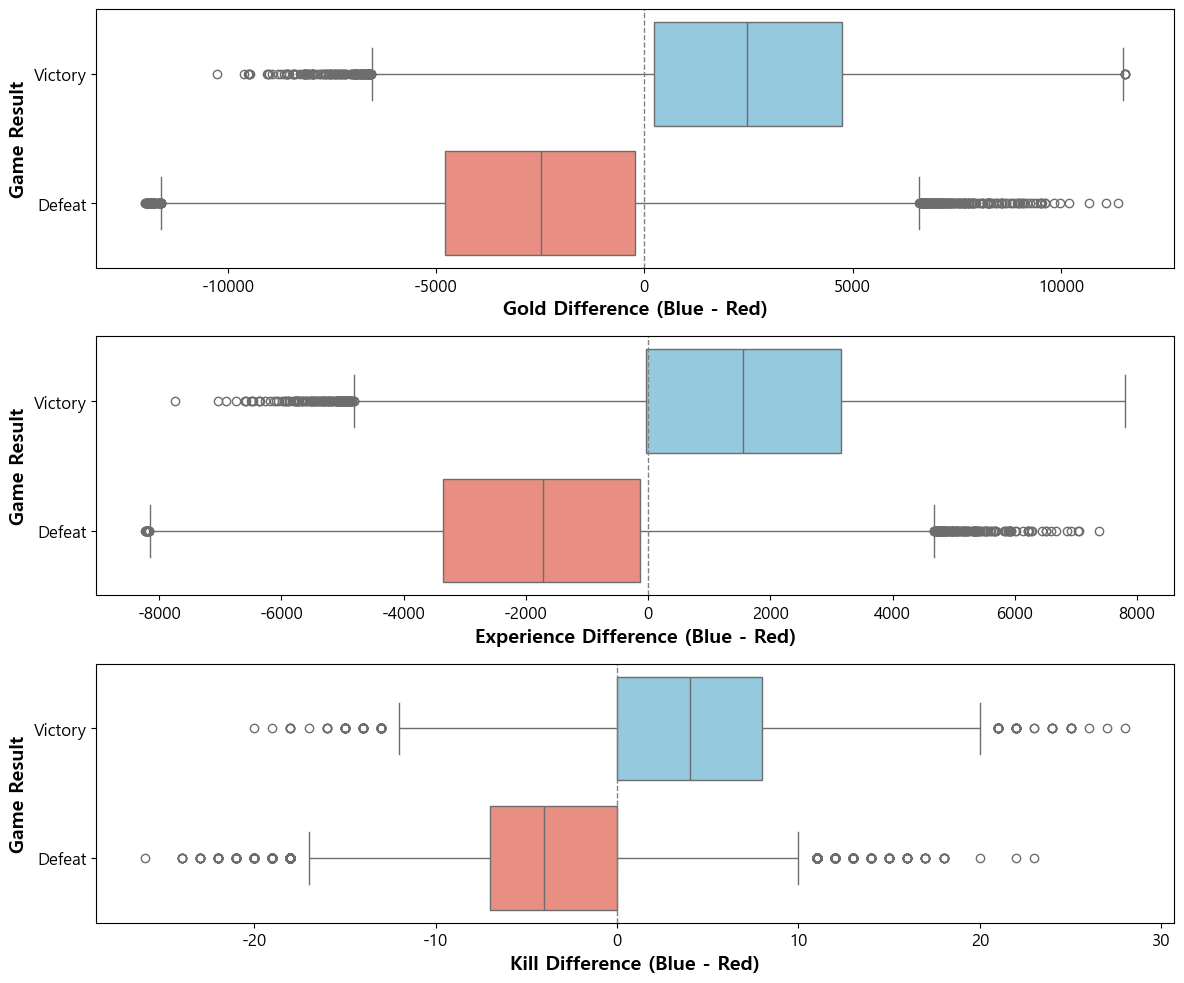


                [그림 2. 승/패 집단 간 킬, 골드, 경험치 격차의 분포 비교]                 


## 5. 변수 간 다중공선성(상관관계) 분석 ##


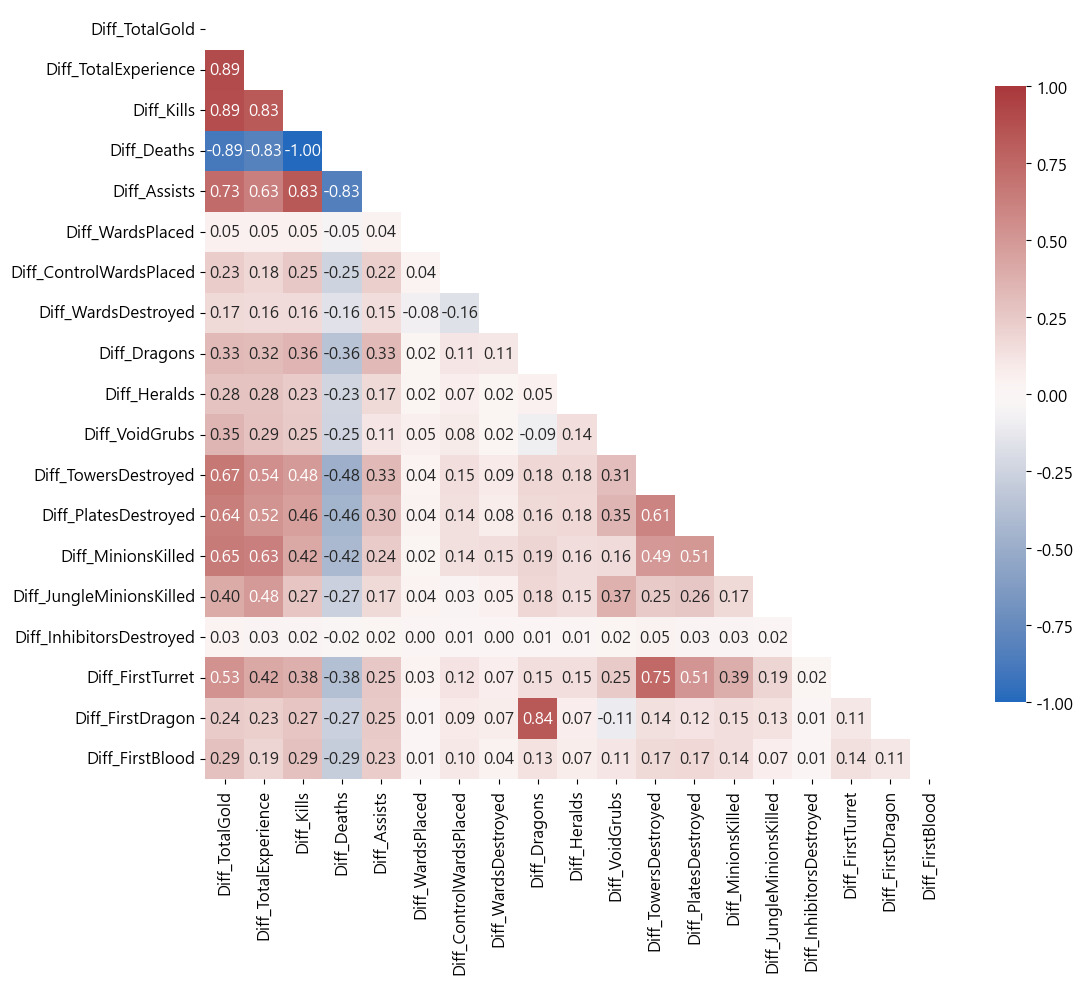


                     [그림 3. 수치형 독립변수 간의 상관관계 히트맵]                     

- [해석] 킬(Kills), 골드(Gold), 경험치(Exp) 간에는 매우 강한 상관관계(0.8 이상)가 존재하여
         서로 독립적이지 않음을 확인했습니다.

## 6. 그래피컬 모델: 승리 메커니즘의 인과 구조 시각화 ##


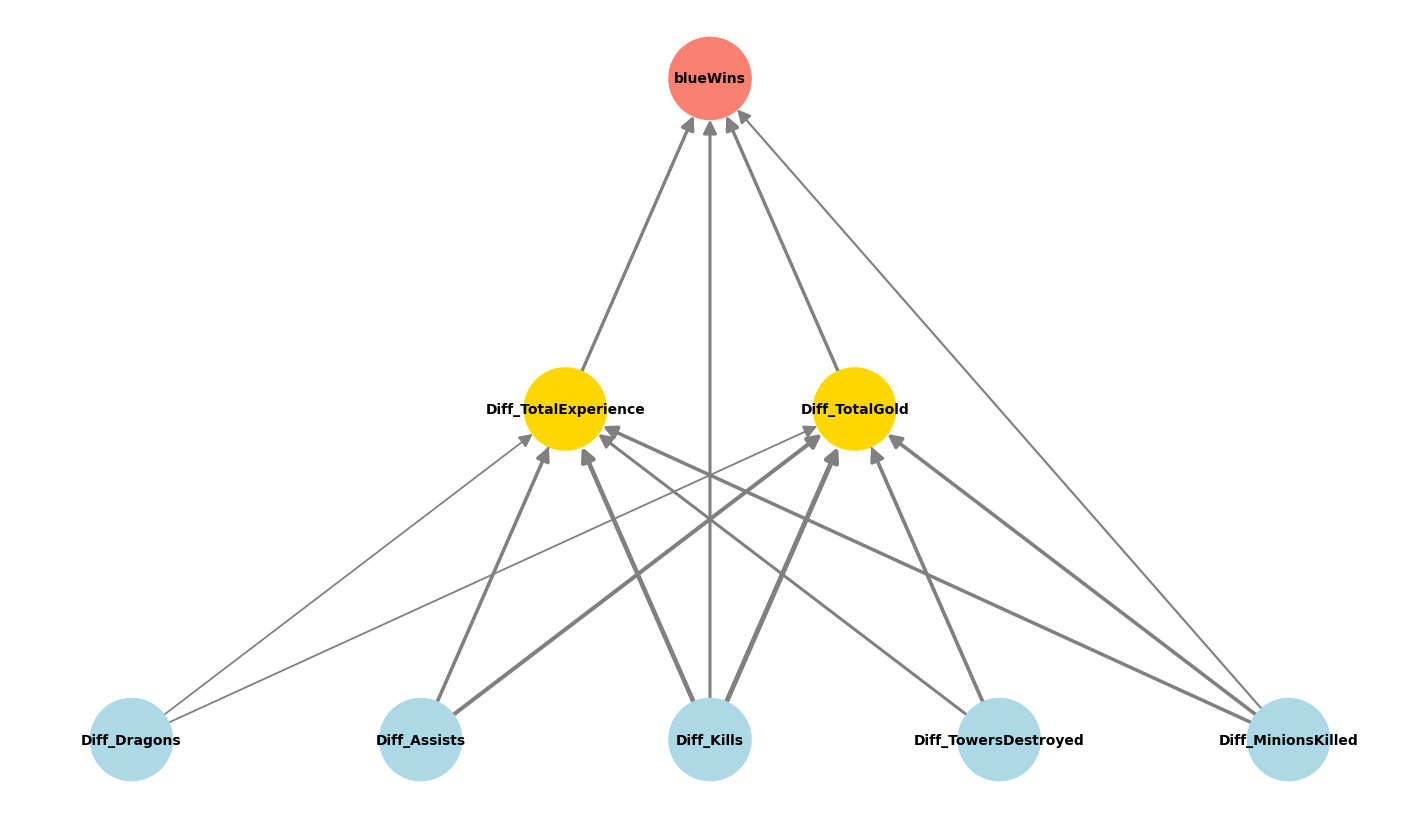


     [그림 4. 그래피컬 모델: 15분 데이터의 인과 구조 (Action → Resource → Result)]     

- 상관계수 임계값(Threshold): 0.3
- 해석: 플레이어의 행동(Action)이 자원(Resource)으로 환산되고, 이것이 승리(Result)로 직결됨을 보여줍니다.

## 7. [결론] 골드 격차에 따른 승률 분석 (항복 및 승리 확신 구간) ##


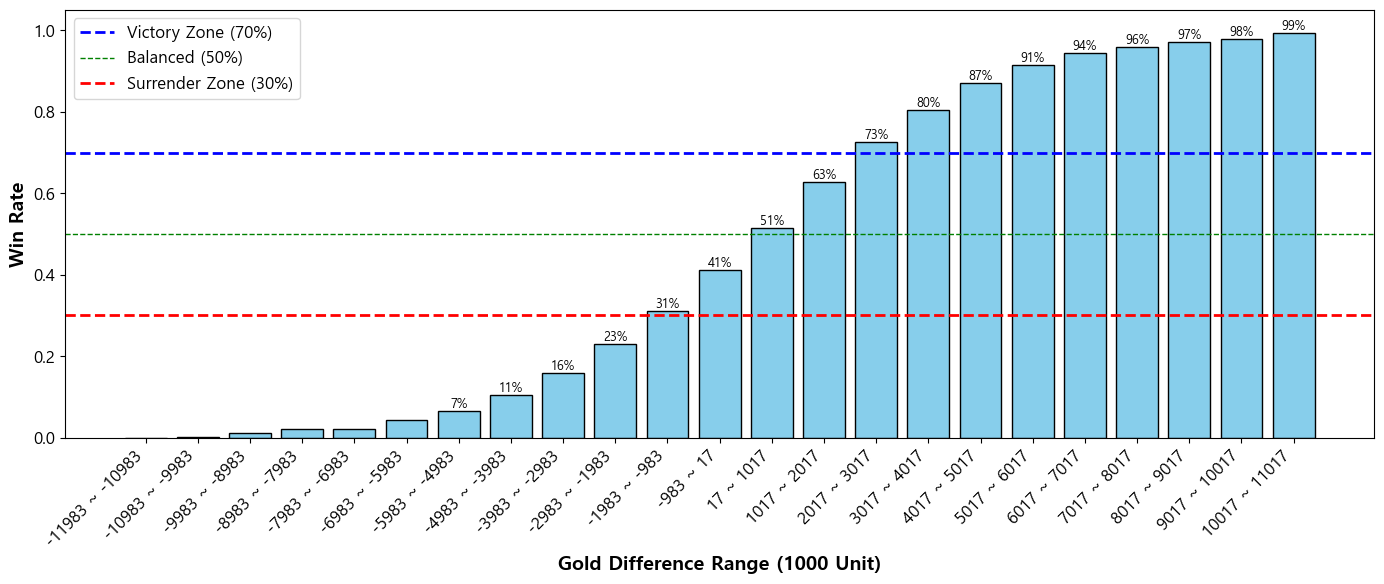


                 [그림 5. 골드 격차 구간별 승률 변화 (항복/승리 기준점)]                  

[최종 결론]
1. 조기 항복(Surrender) 고려 시점: 골드 차이 (-2983, -1983] 구간 이하
   (승률 30% 미만으로 급락하여 역전 가능성이 매우 낮음)
2. 승리 확신(Victory) 시점: 골드 차이 (2017, 3017] 구간 이상
   (승률 70% 이상으로 안정권 진입)


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx

# ==============================================================================
# [설정] 그래프 스타일 (보고서용)
# ==============================================================================
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

def print_caption(text, type="figure"):
    print("\n" + "="*70)
    print(f"[{text}]".center(70))
    print("="*70 + "\n")

# 시각화용 파생변수 (0/1 -> Defeat/Victory)
if 'Result' not in df.columns:
    df['Result'] = df['blueWins'].map({1: 'Victory', 0: 'Defeat'})

# ------------------------------------------------------------------------------
# 1. 주요 변수(3대장) 분포 상세 시각화 (Boxplot)
# ------------------------------------------------------------------------------
print("\n## 4-3. 핵심 변수(골드, 경험치, 킬)의 승패별 분포 비교 ##")

key_metrics = ['Diff_TotalGold', 'Diff_TotalExperience', 'Diff_Kills']
metric_names = ['Gold Difference', 'Experience Difference', 'Kill Difference']

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

for i, (col, name) in enumerate(zip(key_metrics, metric_names)):
    # 타겟(Result)을 Y축에 배치 (가로형 Boxplot)
    sns.boxplot(x=col, y='Result', data=df, ax=axes[i], 
                palette={'Victory': 'skyblue', 'Defeat': 'salmon'}, 
                orient='h', order=['Victory', 'Defeat'])
    
    axes[i].set_title('') # 제목 제거
    axes[i].set_ylabel('Game Result', fontweight='bold')
    axes[i].set_xlabel(f'{name} (Blue - Red)', fontweight='bold')
    axes[i].axvline(0, color='gray', linestyle='--', linewidth=1) # 0점 기준선

plt.tight_layout()
plt.show()

print_caption("그림 2. 승/패 집단 간 킬, 골드, 경험치 격차의 분포 비교", type="figure")


# ------------------------------------------------------------------------------
# 2. 변수 간 상관관계 히트맵 (다중공선성 확인)
# ------------------------------------------------------------------------------
print("\n## 5. 변수 간 다중공선성(상관관계) 분석 ##")

# 분석 대상: Diff 변수들 (범주형 제외)
target_features = [col for col in df.columns if col.startswith('Diff_')]
corr_matrix = df[target_features].corr()

plt.figure(figsize=(12, 10))
# 대각선 위쪽 가리기 (중복 정보 제거)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", 
            cmap='vlag', center=0, vmin=-1, vmax=1,
            cbar_kws={"shrink": .8})

plt.title('') 
plt.show()

print_caption("그림 3. 수치형 독립변수 간의 상관관계 히트맵", type="figure")
print("- [해석] 킬(Kills), 골드(Gold), 경험치(Exp) 간에는 매우 강한 상관관계(0.8 이상)가 존재하여")
print("         서로 독립적이지 않음을 확인했습니다.")


# ------------------------------------------------------------------------------
# 3. 그래피컬 모델 (인과 구조 시각화)
# ------------------------------------------------------------------------------
print("\n## 6. 그래피컬 모델: 승리 메커니즘의 인과 구조 시각화 ##")

# 1) 모델링 준비
# 실제 컬럼명 매핑 (CSV 컬럼명에 맞춰 수정됨)
diff_map = {
    'TotalGold': 'Diff_TotalGold', 'TotalExperience': 'Diff_TotalExperience',
    'Kills': 'Diff_Kills', 'Assists': 'Diff_Assists', 'Deaths': 'Diff_Deaths',
    'Dragons': 'Diff_Dragons', 'TowersDestroyed': 'Diff_TowersDestroyed',
    'MinionsKilled': 'Diff_MinionsKilled' 
}

G = nx.DiGraph()

# 2) 계층 정의 (Action -> Resource -> Result)
layers = {
    'Action': ['Diff_Kills', 'Diff_Assists', 'Diff_Dragons', 'Diff_TowersDestroyed', 'Diff_MinionsKilled'],
    'Resource': ['Diff_TotalGold', 'Diff_TotalExperience'],
    'Result': ['blueWins']
}

# 3) 노드 추가
node_map = {}
valid_nodes = []
for layer, nodes in layers.items():
    for node in nodes:
        if node in df.columns or node == 'blueWins':
            G.add_node(node, layer=layer)
            node_map[node] = layer
            valid_nodes.append(node)

# 4) 엣지 연결 (Threshold 0.3 적용)
# 드래곤 등 연결성이 약한 노드를 보여주기 위해 임계값을 0.3으로 설정
threshold = 0.3 
layer_order = {'Action': 0, 'Resource': 1, 'Result': 2}
corr_matrix_graph = df[valid_nodes].corr()

for u in valid_nodes:
    for v in valid_nodes:
        if u == v: continue
        # 하위 계층 -> 상위 계층으로만 연결 (Causal Direction)
        if layer_order.get(node_map.get(u)) < layer_order.get(node_map.get(v)):
            corr_val = abs(corr_matrix_graph.loc[u, v])
            if corr_val > threshold:
                G.add_edge(u, v, weight=corr_val)

# 5) 시각화
plt.figure(figsize=(14, 8))
pos = nx.multipartite_layout(G, subset_key='layer', align='horizontal')

# 노드 색상 구분
colors = ['lightblue' if node_map[n]=='Action' else 'gold' if node_map[n]=='Resource' else 'salmon' for n in G.nodes()]

nx.draw(G, pos, with_labels=True, node_size=3500, font_size=10, font_weight='bold',
        node_color=colors, edge_color='gray', arrowsize=20, 
        width=[G[u][v]['weight']*4 for u,v in G.edges()]) # 선 굵기 강조

plt.axis('off')
plt.tight_layout()
plt.show()

print_caption("그림 4. 그래피컬 모델: 15분 데이터의 인과 구조 (Action → Resource → Result)", type="figure")
print(f"- 상관계수 임계값(Threshold): {threshold}")
print("- 해석: 플레이어의 행동(Action)이 자원(Resource)으로 환산되고, 이것이 승리(Result)로 직결됨을 보여줍니다.")


# ------------------------------------------------------------------------------
# 4. 골드 격차별 승률 분석 (항복 기준점 도출)
# ------------------------------------------------------------------------------
print("\n## 7. [결론] 골드 격차에 따른 승률 분석 (항복 및 승리 확신 구간) ##")

# 1) 1000 단위 구간화
bins = range(int(df['Diff_TotalGold'].min()), int(df['Diff_TotalGold'].max()) + 1000, 1000)
df['Gold_Bin'] = pd.cut(df['Diff_TotalGold'], bins=bins)

# 2) 구간별 승률 집계 (샘플 수 100개 이상인 구간만)
win_stats = df.groupby('Gold_Bin')['blueWins'].agg(['mean', 'count'])
win_stats = win_stats[win_stats['count'] > 100] 

# 3) 시각화
plt.figure(figsize=(14, 6))

# 라벨 정리
labels = [str(i).replace('(','').replace(']','').replace(',',' ~') for i in win_stats.index]
bars = plt.bar(labels, win_stats['mean'], color='skyblue', edgecolor='black')

# 기준선 (30%, 50%, 70%)
plt.axhline(0.7, color='blue', linestyle='--', linewidth=2, label='Victory Zone (70%)')
plt.axhline(0.5, color='green', linestyle='--', linewidth=1, label='Balanced (50%)')
plt.axhline(0.3, color='red', linestyle='--', linewidth=2, label='Surrender Zone (30%)')

plt.xticks(rotation=45, ha='right')
plt.ylabel('Win Rate', fontweight='bold')
plt.xlabel('Gold Difference Range (1000 Unit)', fontweight='bold')
plt.legend(loc='upper left')
plt.ylim(0, 1.05)

# 막대 위 수치 표시
for rect in bars:
    height = rect.get_height()
    if height > 0.05: # 너무 작은 값은 표시 생략
        plt.text(rect.get_x() + rect.get_width()/2.0, height, f'{height*100:.0f}%', 
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print_caption("그림 5. 골드 격차 구간별 승률 변화 (항복/승리 기준점)", type="figure")

# 4) 결론 자동 출력
surrender_limit = win_stats[win_stats['mean'] < 0.3].index.max()
victory_limit = win_stats[win_stats['mean'] > 0.7].index.min()

print(f"[최종 결론]")
print(f"1. 조기 항복(Surrender) 고려 시점: 골드 차이 {surrender_limit} 구간 이하")
print(f"   (승률 30% 미만으로 급락하여 역전 가능성이 매우 낮음)")
print(f"2. 승리 확신(Victory) 시점: 골드 차이 {victory_limit} 구간 이상")
print(f"   (승률 70% 이상으로 안정권 진입)")

In [26]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 (이전 단계의 df 사용)
# Diff 변수만 선택 (Target 제외)
features = [col for col in df.columns if col.startswith('Diff_')]
X = df[features]
y = df['blueWins']

# 2. 데이터 분할 (Stratify 적용)
# 학습:평가 = 8:2
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training Data: {X_train.shape}")
print(f"Test Data: {X_test.shape}")

# 3. 전처리 파이프라인 (MinMax Scaling -> PCA)
# 로지스틱 회귀 & DNN 용 데이터셋 생성
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA 적용 (분산 보존율 95% 설정)
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA 적용 후 Feature 개수: {X_train_pca.shape[1]} (Original: {X_train.shape[1]})")

Training Data: (74688, 19)
Test Data: (18673, 19)
PCA 적용 후 Feature 개수: 7 (Original: 19)


In [27]:
from sklearn.linear_model import LogisticRegression

# 1. 모델 및 하이퍼파라미터 그리드 설정
lr_model = LogisticRegression(penalty='l2', solver='liblinear', random_state=42)

# C값(규제 강도의 역수) 탐색
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}

# 2. GridSearchCV (10-Fold)
grid_lr = GridSearchCV(lr_model, param_grid_lr, cv=10, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_pca, y_train)

# 3. 최적 모델 저장 및 예측
best_lr = grid_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test_pca)
y_prob_lr = best_lr.predict_proba(X_test_pca)[:, 1]

print(f"Logistic Regression Best Params: {grid_lr.best_params_}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")

Logistic Regression Best Params: {'C': 0.1}
Test Accuracy: 0.7763


Random Forest Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Test Accuracy: 0.7784


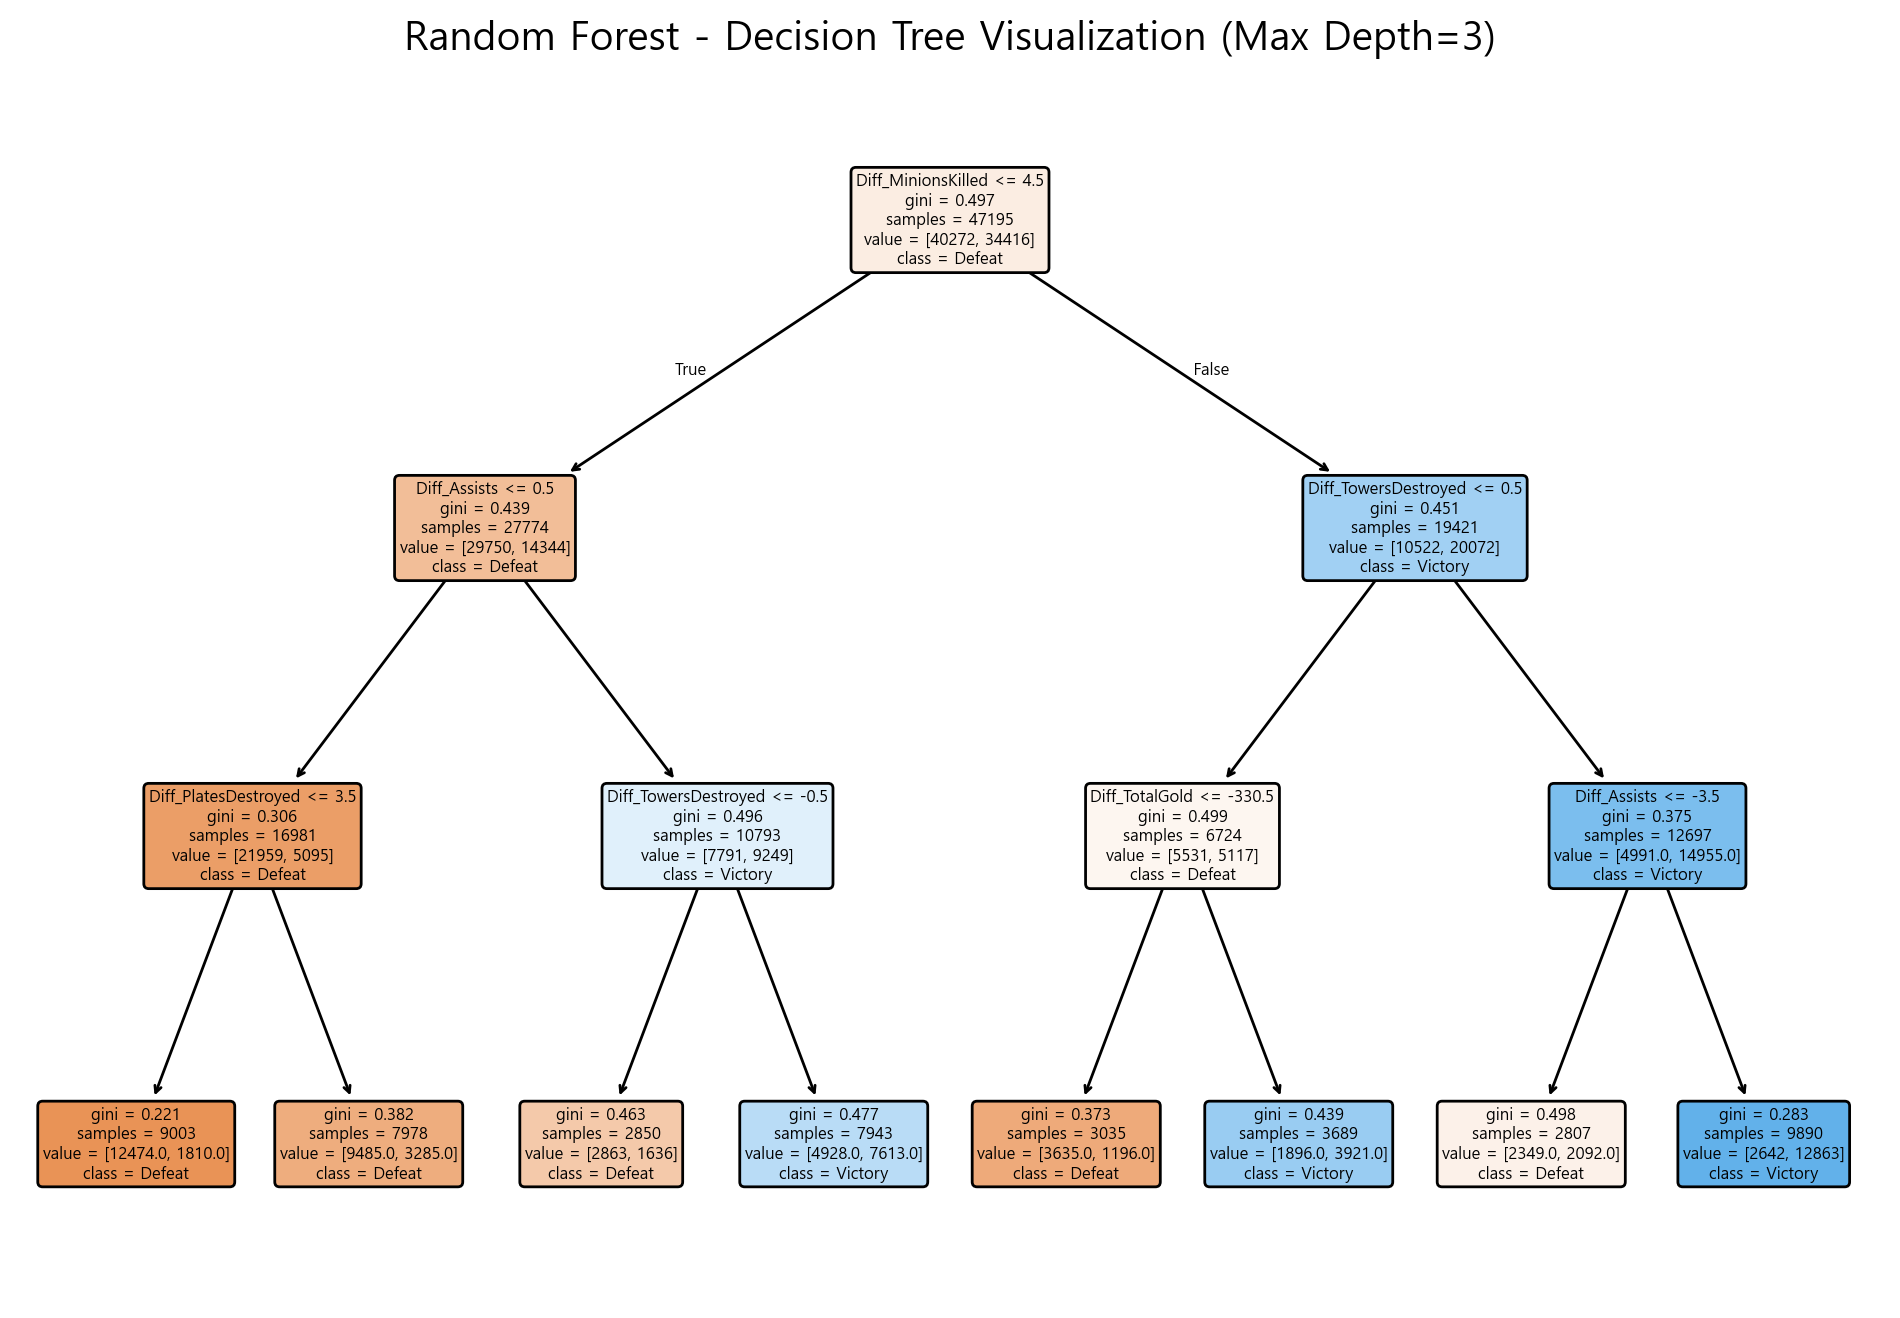

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

# 1. 모델 및 하이퍼파라미터 설정
rf_model = RandomForestClassifier(random_state=42)

# 시간이 오래 걸리므로 핵심 파라미터 위주로 탐색
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 2. GridSearchCV (10-Fold)
grid_rf = GridSearchCV(rf_model, param_grid_rf, cv=10, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

# 3. 최적 모델 저장 및 예측
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print(f"Random Forest Best Params: {grid_rf.best_params_}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

# ------------------------------------------------------------------
# [핵심] 트리 모델 시각화 (교수님 코드 스타일 반영)
# 전체 트리는 너무 크므로, 시각화용으로 depth가 제한된 모델을 하나 그려서 보여줌
# ------------------------------------------------------------------
viz_rf = RandomForestClassifier(n_estimators=1, max_depth=3, random_state=42)
viz_rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8), dpi=200) # 교수님 요청 dpi=200 반영
plot_tree(viz_rf.estimators_[0], 
          feature_names=X.columns, 
          class_names=['Defeat', 'Victory'], 
          filled=True, 
          rounded=True)
plt.title("Random Forest - Decision Tree Visualization (Max Depth=3)")
plt.show()

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Test Accuracy: 0.7781


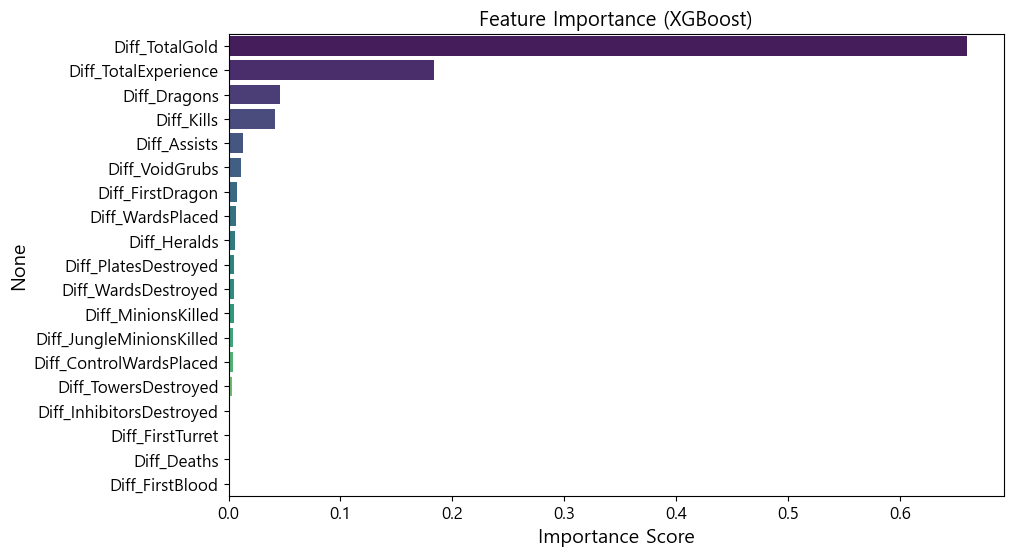

In [29]:
from xgboost import XGBClassifier

# 1. 모델 설정
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# 하이퍼파라미터 (학습 시간 고려하여 경량화)
param_grid_xgb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

# 2. GridSearchCV
grid_xgb = GridSearchCV(xgb_model, param_grid_xgb, cv=10, scoring='accuracy', n_jobs=-1)
grid_xgb.fit(X_train, y_train)

# 3. 예측
best_xgb = grid_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

print(f"XGBoost Best Params: {grid_xgb.best_params_}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")

# ------------------------------------------------------------------
# 변수 중요도 시각화 (그래피컬 모델과 비교 분석용)
# ------------------------------------------------------------------
importances = pd.Series(best_xgb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.show()

In [30]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# 1. 모델 구조 설계 (Dense 방식)
# PCA 성분 개수에 맞춰 Input Dimension 설정
input_dim = X_train_pca.shape[1]

model = Sequential([
    # Input Layer & Hidden Layer 1
    Dense(64, input_dim=input_dim, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden Layer 2
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Output Layer (Sigmoid for Binary Classification)
    Dense(1, activation='sigmoid')
])

# 2. 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. 학습 (EarlyStopping 적용)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_pca, y_train, 
                    validation_split=0.2, 
                    epochs=50, 
                    batch_size=64, 
                    callbacks=[early_stop], 
                    verbose=1)

# 4. 예측
y_prob_dnn = model.predict(X_test_pca).ravel()
y_pred_dnn = (y_prob_dnn > 0.5).astype(int)

print(f"DNN Test Accuracy: {accuracy_score(y_test, y_pred_dnn):.4f}")

Epoch 1/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.7564 - loss: 0.5064 - val_accuracy: 0.7753 - val_loss: 0.4643
Epoch 2/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7725 - loss: 0.4749 - val_accuracy: 0.7770 - val_loss: 0.4636
Epoch 3/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7733 - loss: 0.4739 - val_accuracy: 0.7773 - val_loss: 0.4619
Epoch 4/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7737 - loss: 0.4711 - val_accuracy: 0.7769 - val_loss: 0.4653
Epoch 5/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7741 - loss: 0.4720 - val_accuracy: 0.7774 - val_loss: 0.4630
Epoch 6/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7746 - loss: 0.4707 - val_accuracy: 0.7790 - val_loss: 0.4620
Epoch 7/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7752 - loss: 0.4699 - val_accuracy: 0.7785 - val_loss: 0.4617
Epoch 8/50
934/934 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7758 - loss: 0.4693 - val_accuracy: 0.


[최종 모델 성능 비교]
                 Model  Accuracy  Precision  Recall  F1-Score     AUC
0  Logistic Regression    0.7763     0.7666  0.7425    0.7544  0.8603
1        Random Forest    0.7784     0.7714  0.7405    0.7556  0.8604
2              XGBoost    0.7781     0.7703  0.7416    0.7557  0.8612
3                  DNN    0.7764     0.7692  0.7381    0.7533  0.8599


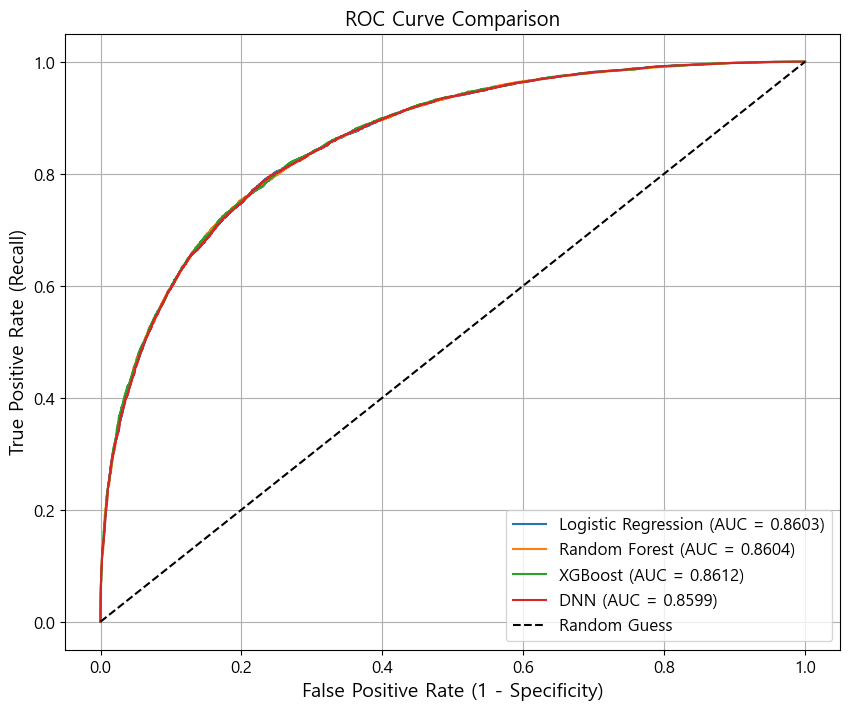

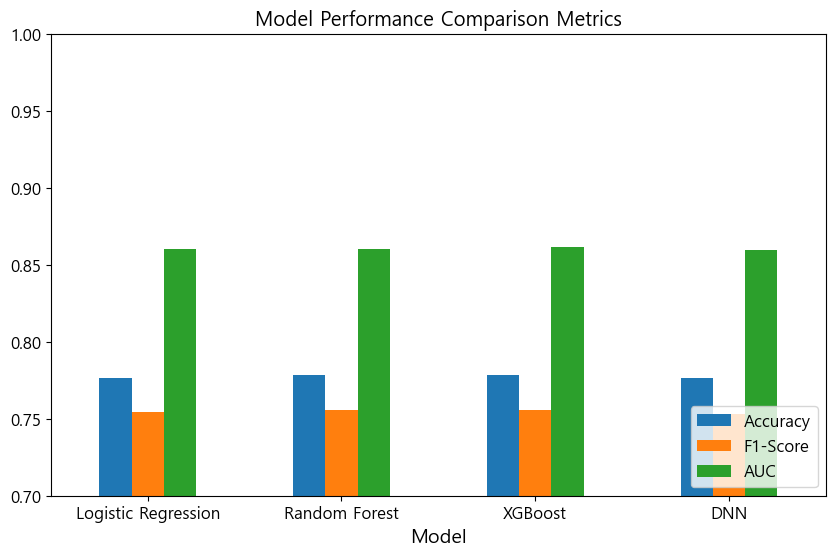

In [31]:
# 1. 성능 평가 지표 취합
def get_metrics(y_test, y_pred, y_prob, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_prob)
    }

results = []
results.append(get_metrics(y_test, y_pred_lr, y_prob_lr, 'Logistic Regression'))
results.append(get_metrics(y_test, y_pred_rf, y_prob_rf, 'Random Forest'))
results.append(get_metrics(y_test, y_pred_xgb, y_prob_xgb, 'XGBoost'))
results.append(get_metrics(y_test, y_pred_dnn, y_prob_dnn, 'DNN'))

results_df = pd.DataFrame(results)
print("\n[최종 모델 성능 비교]")
print(results_df.round(4))

# ------------------------------------------------------------------
# 2. ROC Curve 종합 시각화
# ------------------------------------------------------------------
plt.figure(figsize=(10, 8))

models = [
    ('Logistic Regression', y_prob_lr),
    ('Random Forest', y_prob_rf),
    ('XGBoost', y_prob_xgb),
    ('DNN', y_prob_dnn)
]

for name, y_prob in models:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# ------------------------------------------------------------------
# 3. 성능 비교 바 차트
# ------------------------------------------------------------------
results_df.set_index('Model')[['Accuracy', 'F1-Score', 'AUC']].plot(kind='bar', figsize=(10, 6), ylim=(0.7, 1.0))
plt.title("Model Performance Comparison Metrics")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()


## 8. Real-world Simulation: My Match History Analysis (XGBoost Only) ##


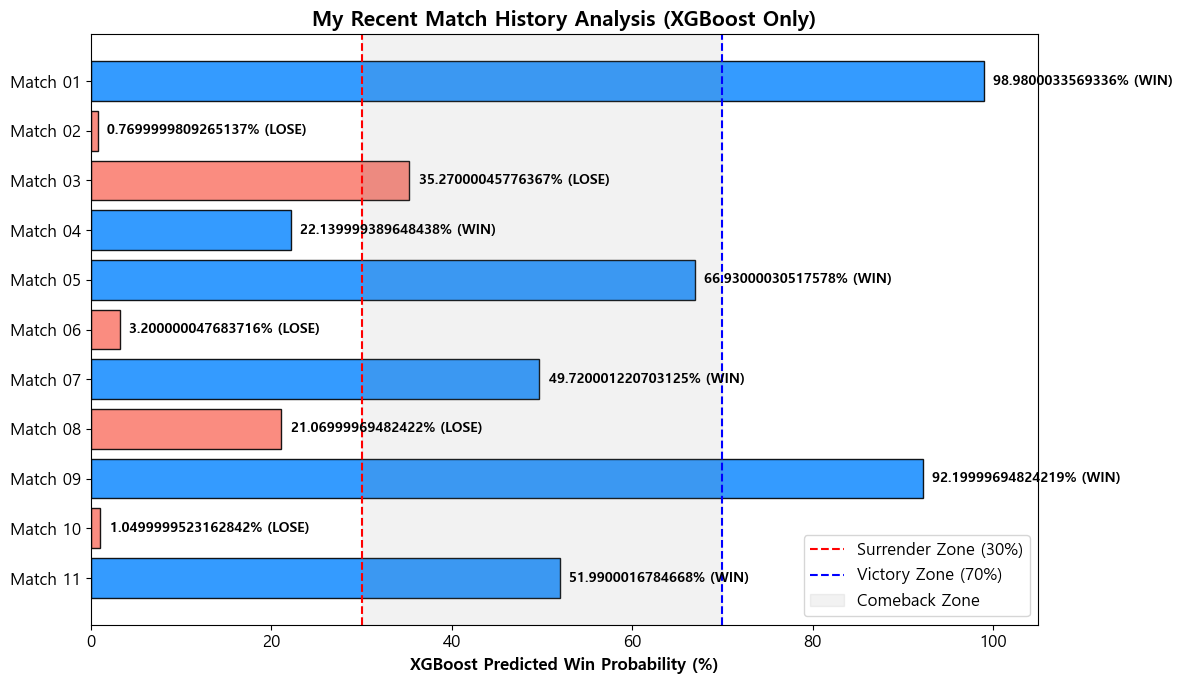

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("\n## 8. Real-world Simulation: My Match History Analysis (XGBoost Only) ##")

# [데이터 입력] 실제 플레이한 11경기 데이터 하드코딩
my_matches = [
    # Match 01: (승리) 시작부터 전 라인이 압도하여 20분 만에 넥서스를 깬 완승 경기
    {
        "Match": "Match 01", "blueWins": 1,
        "Diff_TotalGold": 9500, "Diff_TotalExperience": 7200, "Diff_Kills": 18, "Diff_Deaths": -18, "Diff_Assists": 25,
        "Diff_WardsPlaced": 8, "Diff_ControlWardsPlaced": 4, "Diff_WardsDestroyed": 5, "Diff_Dragons": 3, "Diff_Heralds": 2, "Diff_VoidGrubs": 4, "Diff_TowersDestroyed": 5, "Diff_PlatesDestroyed": 7,
        "Diff_MinionsKilled": 55, "Diff_JungleMinionsKilled": 22, "Diff_InhibitorsDestroyed": 1, "Diff_FirstTurret": 1, "Diff_FirstDragon": 1, "Diff_FirstBlood": 1
    },

    # Match 02: (패배) 초반 인베이드 사고 후 전 라인이 터져서 15분에 항복한 경기
    {
        "Match": "Match 02", "blueWins": 0,
        "Diff_TotalGold": -8200, "Diff_TotalExperience": -6500, "Diff_Kills": -16, "Diff_Deaths": 16, "Diff_Assists": -12,
        "Diff_WardsPlaced": -6, "Diff_ControlWardsPlaced": -4, "Diff_WardsDestroyed": -3, "Diff_Dragons": -2, "Diff_Heralds": -1, "Diff_VoidGrubs": -3, "Diff_TowersDestroyed": -4, "Diff_PlatesDestroyed": -5,
        "Diff_MinionsKilled": -45, "Diff_JungleMinionsKilled": -18, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 03: (패배) 팽팽하게 잘 싸웠으나, 후반 중요 한타 한 번 패배로 그대로 게임이 끝난 아쉬운 석패
    {
        "Match": "Match 03", "blueWins": 0,
        "Diff_TotalGold": -1200, "Diff_TotalExperience": -800, "Diff_Kills": -2, "Diff_Deaths": 2, "Diff_Assists": -5,
        "Diff_WardsPlaced": 3, "Diff_ControlWardsPlaced": 1, "Diff_WardsDestroyed": 2, "Diff_Dragons": 0, "Diff_Heralds": 0, "Diff_VoidGrubs": -1, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": -1,
        "Diff_MinionsKilled": -5, "Diff_JungleMinionsKilled": -2, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 1, "Diff_FirstBlood": 0
    },

    # Match 04: (승리) 초반에 불리했으나, 상대방이 방심하고 던진 것을 받아먹고 기적적으로 역전한 경기
    {
        "Match": "Match 04", "blueWins": 1,
        "Diff_TotalGold": -3100, "Diff_TotalExperience": -2100, "Diff_Kills": -6, "Diff_Deaths": 6, "Diff_Assists": -9,
        "Diff_WardsPlaced": -2, "Diff_ControlWardsPlaced": -1, "Diff_WardsDestroyed": -1, "Diff_Dragons": 1, "Diff_Heralds": 0, "Diff_VoidGrubs": 0, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": -2,
        "Diff_MinionsKilled": -20, "Diff_JungleMinionsKilled": -5, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 05: (승리) 무리하지 않고 야금야금 이득을 챙겨서 스노우볼을 굴려 안전하게 이긴 경기
    {
        "Match": "Match 05", "blueWins": 1,
        "Diff_TotalGold": 1300, "Diff_TotalExperience": 900, "Diff_Kills": 4, "Diff_Deaths": -4, "Diff_Assists": 6,
        "Diff_WardsPlaced": 1, "Diff_ControlWardsPlaced": 1, "Diff_WardsDestroyed": 0, "Diff_Dragons": 1, "Diff_Heralds": 0, "Diff_VoidGrubs": 1, "Diff_TowersDestroyed": 1, "Diff_PlatesDestroyed": 1,
        "Diff_MinionsKilled": 12, "Diff_JungleMinionsKilled": 2, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1
    },

    # Match 06: (패배) 우리 정글러가 상대에게 완전히 말려서 성장 차이가 심해 무력하게 진 경기
    {
        "Match": "Match 06", "blueWins": 0,
        "Diff_TotalGold": -5200, "Diff_TotalExperience": -4100, "Diff_Kills": -11, "Diff_Deaths": 11, "Diff_Assists": -9,
        "Diff_WardsPlaced": -5, "Diff_ControlWardsPlaced": -2, "Diff_WardsDestroyed": -2, "Diff_Dragons": -3, "Diff_Heralds": -1, "Diff_VoidGrubs": -2, "Diff_TowersDestroyed": -3, "Diff_PlatesDestroyed": -4,
        "Diff_MinionsKilled": -12, "Diff_JungleMinionsKilled": -28, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 07: (승리) 40분 넘는 장기전 끝에 장로 드래곤 버프를 획득하여 한타를 대승한 혈전
    {
        "Match": "Match 07", "blueWins": 1,
        "Diff_TotalGold": -150, "Diff_TotalExperience": 80, "Diff_Kills": 1, "Diff_Deaths": -1, "Diff_Assists": 1,
        "Diff_WardsPlaced": 2, "Diff_ControlWardsPlaced": 0, "Diff_WardsDestroyed": 1, "Diff_Dragons": 0, "Diff_Heralds": 0, "Diff_VoidGrubs": 0, "Diff_TowersDestroyed": 0, "Diff_PlatesDestroyed": 0,
        "Diff_MinionsKilled": 6, "Diff_JungleMinionsKilled": -3, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 1, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1
    },

    # Match 08: (패배) 싸움(킬)은 이겼으나, 상대가 교전을 피하고 타워만 밀어서 운영에 휘둘리다 진 경기
    {
        "Match": "Match 08", "blueWins": 0,
        "Diff_TotalGold": -2100, "Diff_TotalExperience": -1600, "Diff_Kills": 5, "Diff_Deaths": -5, "Diff_Assists": 2,
        "Diff_WardsPlaced": -4, "Diff_ControlWardsPlaced": -1, "Diff_WardsDestroyed": -1, "Diff_Dragons": -1, "Diff_Heralds": 0, "Diff_VoidGrubs": -1, "Diff_TowersDestroyed": -4, "Diff_PlatesDestroyed": -2,
        "Diff_MinionsKilled": -22, "Diff_JungleMinionsKilled": -6, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 1, "Diff_FirstBlood": 0
    },

    # Match 09: (승리) 우리 팀 탑 라이너가 괴물같이 성장해서 혼자 다 죽이고 캐리한 경기 (버스 탑승)
    {
        "Match": "Match 09", "blueWins": 1,
        "Diff_TotalGold": 4600, "Diff_TotalExperience": 4100, "Diff_Kills": 9, "Diff_Deaths": -9, "Diff_Assists": 7,
        "Diff_WardsPlaced": 4, "Diff_ControlWardsPlaced": 3, "Diff_WardsDestroyed": 2, "Diff_Dragons": 1, "Diff_Heralds": 1, "Diff_VoidGrubs": 3, "Diff_TowersDestroyed": 4, "Diff_PlatesDestroyed": 5,
        "Diff_MinionsKilled": 42, "Diff_JungleMinionsKilled": 11, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 1, "Diff_FirstDragon": 1, "Diff_FirstBlood": 1
    },

    # Match 10: (패배) 초반 라인전 단계에서 게임이 터져 팀원들이 의욕을 잃고 '미드 오픈' 한 경기
    {
        "Match": "Match 10", "blueWins": 0,
        "Diff_TotalGold": -7200, "Diff_TotalExperience": -5600, "Diff_Kills": -13, "Diff_Deaths": 13, "Diff_Assists": -16,
        "Diff_WardsPlaced": -7, "Diff_ControlWardsPlaced": -3, "Diff_WardsDestroyed": -4, "Diff_Dragons": -2, "Diff_Heralds": -1, "Diff_VoidGrubs": -3, "Diff_TowersDestroyed": -5, "Diff_PlatesDestroyed": -6,
        "Diff_MinionsKilled": -38, "Diff_JungleMinionsKilled": -12, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 0
    },

    # Match 11: (승리) 킬 스코어는 밀렸지만, 사이드 운영으로 CS와 골드를 더 챙겨 '돈의 힘'으로 찍어 누른 경기
    {
        "Match": "Match 11", "blueWins": 1,
        "Diff_TotalGold": 2610, "Diff_TotalExperience": -2726, "Diff_Kills": -3, "Diff_Deaths": 3, "Diff_Assists": -5,
        "Diff_WardsPlaced": -2, "Diff_ControlWardsPlaced": 0, "Diff_WardsDestroyed": 0, "Diff_Dragons": -1, "Diff_Heralds": 0, "Diff_VoidGrubs": 1, "Diff_TowersDestroyed": -1, "Diff_PlatesDestroyed": 0,
        "Diff_MinionsKilled": 35, "Diff_JungleMinionsKilled": 10, "Diff_InhibitorsDestroyed": 0, "Diff_FirstTurret": 0, "Diff_FirstDragon": 0, "Diff_FirstBlood": 1
    }
]

# 2. DataFrame 변환 및 모델 예측
df_graph = pd.DataFrame(my_matches)
feature_names = X.columns.tolist()

# 예측을 위한 데이터 준비
X_graph = df_graph[feature_names]

# [수정] 앙상블 제거: 오직 XGBoost 모델(best_xgb)만 사용
# (DNN을 위해 사용했던 scaler, pca 등 불필요한 과정은 생략)
p_xgb = best_xgb.predict_proba(X_graph)[:, 1]

# 소수점 둘째 자리까지 반올림
df_graph['Win_Prob'] = (p_xgb * 100).round(2)
df_graph['Result_Str'] = df_graph['blueWins'].apply(lambda x: 'WIN' if x == 1 else 'LOSE')

# 3. 시각화
plt.figure(figsize=(12, 7))

# 색상: WIN=파랑, LOSE=빨강
colors = ['dodgerblue' if x == 1 else 'salmon' for x in df_graph['blueWins']]
bars = plt.barh(df_graph['Match'], df_graph['Win_Prob'], color=colors, edgecolor='black', alpha=0.9)

# 기준선 표시
plt.axvline(30, color='red', linestyle='--', linewidth=1.5, label='Surrender Zone (30%)')
plt.axvline(70, color='blue', linestyle='--', linewidth=1.5, label='Victory Zone (70%)')
plt.axvspan(30, 70, color='gray', alpha=0.1, label='Comeback Zone')

# 그래프 꾸미기
plt.xlabel('XGBoost Predicted Win Probability (%)', fontsize=12, fontweight='bold')
plt.title('My Recent Match History Analysis (XGBoost Only)', fontsize=15, fontweight='bold')
plt.gca().invert_yaxis() # Match 1이 위로 오도록 정렬

# 바 끝에 수치 및 결과 표시
for rect, prob, res in zip(bars, df_graph['Win_Prob'], df_graph['Result_Str']):
    width = rect.get_width()
    label_text = f" {prob}% ({res})"
    plt.text(width + 0.5, rect.get_y() + rect.get_height()/2, label_text, 
             va='center', fontsize=10, fontweight='bold', color='black')

plt.xlim(0, 105) # 텍스트 잘림 방지
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

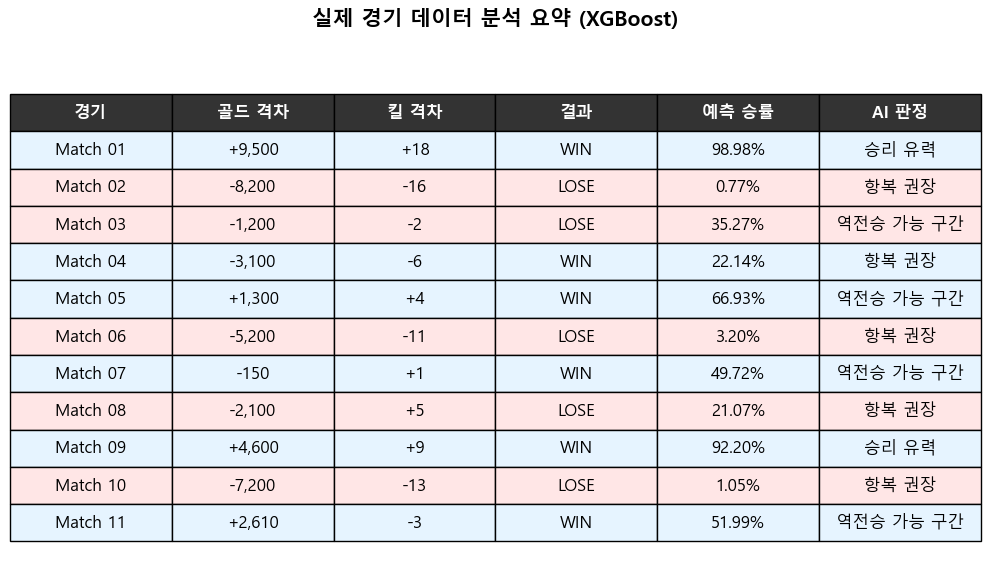

In [47]:
import matplotlib.pyplot as plt

# 1. 테이블에 들어갈 데이터 포맷팅 (df_graph는 이전 코드에서 생성된 데이터프레임)
cell_text = []
for index, row in df_graph.iterrows():
    match_name = row['Match']
    gold_diff = f"{row['Diff_TotalGold']:+,}" # 예: +9,500
    kill_diff = f"{row['Diff_Kills']:+}"      # 예: +18
    result = row['Result_Str']                # WIN / LOSE
    
    # 승률 (소수점 2자리)
    win_prob = f"{row['Win_Prob']:.2f}%"
    
    # AI 판정 로직 (30% 미만, 30~70%, 70% 이상)
    prob_val = row['Win_Prob']
    if prob_val >= 70:
        decision = "승리 유력"
    elif prob_val <= 30:
        decision = "항복 권장"
    else:
        decision = "역전승 가능 구간"
        
    cell_text.append([match_name, gold_diff, kill_diff, result, win_prob, decision])

# 2. 테이블 시각화 설정
plt.figure(figsize=(10, 6)) # 표 크기 조절
plt.axis('off') # 축 숨기기

# 컬럼 이름 설정
col_labels = ['경기', '골드 격차', '킬 격차', '결과', '예측 승률', 'AI 판정']

# 테이블 그리기
table = plt.table(cellText=cell_text,
                  colLabels=col_labels,
                  loc='center',
                  cellLoc='center')

# 3. 스타일 꾸미기
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 2) # (가로, 세로) 크기 배율 조절

# 헤더와 셀 색상 입히기
for (row, col), cell in table.get_celld().items():
    if row == 0: # 헤더(제목) 행
        cell.set_text_props(weight='bold', color='white')
        cell.set_facecolor('#333333')
    else:
        # 결과에 따른 배경색 구분 (WIN: 파랑, LOSE: 빨강)
        result_str = cell_text[row-1][3] # '결과' 컬럼 값 확인
        if result_str == 'WIN':
            cell.set_facecolor('#E6F4FF') # 연한 파랑
        else:
            cell.set_facecolor('#FFE6E6') # 연한 빨강

plt.title("실제 경기 데이터 분석 요약 (XGBoost)", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [ ]:
# 사용된 라이브러리 목록

이 노트북에서 사용된 모든 라이브러리:

- **pandas**: 데이터 조작 및 분석
- **numpy**: 수치 계산 및 배열 처리
- **matplotlib**: 데이터 시각화 (플롯 생성)
- **seaborn**: 통계적 데이터 시각화 (히트맵, 박스플롯 등)
- **scipy**: 과학 계산 (stats 모듈 사용)
- **sklearn**: 머신러닝 라이브러리
  - preprocessing(MinMaxScaler, StandardScaler)
  - model_selection(train_test_split, GridSearchCV, StratifiedKFold)
  - decomposition(PCA)
  - linear_model(LogisticRegression)
  - ensemble(RandomForestClassifier)
  - metrics(accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc)
- **xgboost**: 그래디언트 부스팅 모델
- **tensorflow**: 딥러닝 프레임워크
  - keras.models(Sequential)
  - keras.layers(Dense, Dropout)
- **networkx**: 그래프 및 네트워크 분석
- **warnings**: 경고 메시지 제어
- **matplotlib.font_manager**: 폰트 관리

이 라이브러리들은 가상 환경에서 설치되어 있으며, requirements.txt 파일에 버전 정보가 포함되어 있습니다.